In [ ]:
#drive connection
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#imports
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
#train dataset path
train_dir = "/content/drive/MyDrive/Ai ML/week5/FruitinAmazon/train"

#list of each directories inside train directory
classes = os.listdir(train_dir)
print("Classes:", classes)


Classes: ['guarana', 'acai', 'graviola', 'cupuacu', 'pupunha', 'tucuma']


In [ ]:
images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    images.append((cls, img_path))

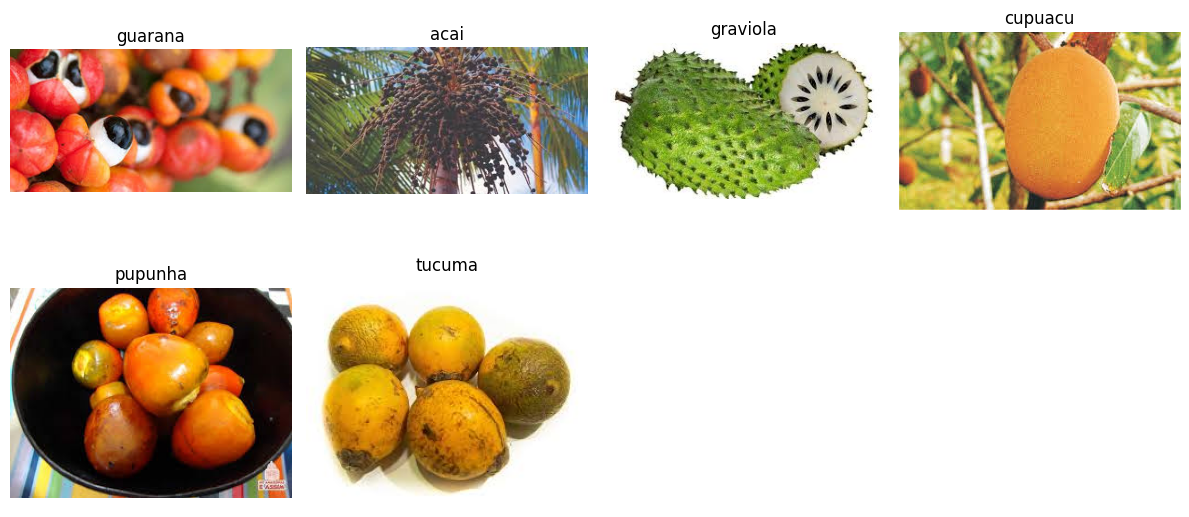

In [ ]:
plt.figure(figsize=(12, 6))

for i, (cls, img_path) in enumerate(images):
    plt.subplot(2, len(images)//2 + 1, i+1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Check for Corrupted Image
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


In [ ]:
#impot and setting vlaue for image data
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

In [ ]:
#convert the pixel value to either 0 or 1.
rescale = tf.keras.layers.Rescaling(1./255)

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compile Module
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train the model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.1250 - loss: 1.8506

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 719ms/step - accuracy: 0.1250 - loss: 1.8918 - val_accuracy: 0.1667 - val_loss: 1.8150
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.3617 - loss: 1.5911

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 540ms/step - accuracy: 0.3194 - loss: 1.6539 - val_accuracy: 0.0556 - val_loss: 1.7767
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.5654 - loss: 1.4151

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 571ms/step - accuracy: 0.5556 - loss: 1.3896 - val_accuracy: 0.3333 - val_loss: 1.5608
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.6464 - loss: 1.1675

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 526ms/step - accuracy: 0.6111 - loss: 1.1722 - val_accuracy: 0.5000 - val_loss: 1.3924
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.7546 - loss: 0.9070

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 642ms/step - accuracy: 0.8472 - loss: 0.4265 - val_accuracy: 0.9444 - val_loss: 0.3615
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 414ms/step - accuracy: 0.9444 - loss: 0.3054 - val_accuracy: 0.7222 - val_loss: 0.7001
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 0.9444 - loss: 0.2628 - val_accuracy: 0.5000 - val_loss: 1.1923
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.9306 - loss: 0.2510 - val_accuracy: 0.8333 - val_loss: 0.4946
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 882ms/step - accuracy: 1.0000 - loss: 0.0878 - val_accuracy: 0.7778 - val_loss: 0.8094
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.8900 - loss: 0.2432

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 550ms/step - accuracy: 0.8889 - loss: 0.2350 - val_accuracy: 0.9444 - val_loss: 0.2643
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 1.0000 - loss: 0.0488

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 1.0000 - loss: 0.0514 - val_accuracy: 0.9444 - val_loss: 0.2148
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 609ms/step - accuracy: 1.0000 - loss: 0.0522 - val_accuracy: 0.8889 - val_loss: 0.3733
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 410ms/step - accuracy: 1.0000 - loss: 0.0534 - val_accuracy: 0.8333 - val_loss: 0.3254
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 1.0000 - loss: 0.0318

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 459ms/step - accuracy: 1.0000 - loss: 0.0338 - val_accuracy: 0.9444 - val_loss: 0.1678
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0108

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 0.1098
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 425ms/step - accuracy: 1.0000 - loss: 0.0269 - val_accuracy: 0.8889 - val_loss: 0.1643
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 426ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.8889 - val_loss: 0.4115
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 0.8333 - val_loss: 0.6356
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.8333 - val_loss: 0.6871
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.8889 - val_loss: 0.5421
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 925ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.8889 - val_loss: 0.3866
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 927ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.8889 - val_loss:

In [ ]:
#Evaluate the Model
test_loss, test_acc = model.evaluate(val_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 1.0000 - loss: 0.1098
Test Loss: 0.10977146029472351
Test Accuracy: 1.0


In [ ]:
#Save the Model
model.save("week5_cnn_model.h5")

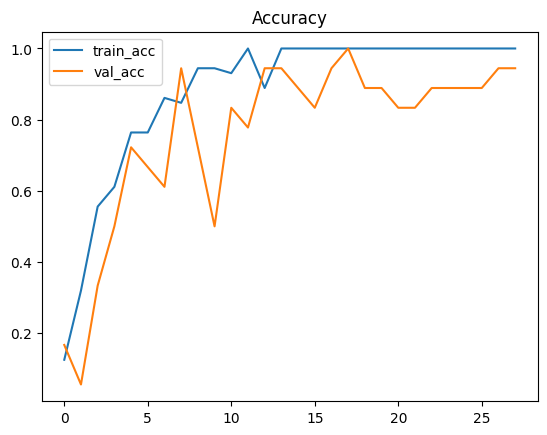

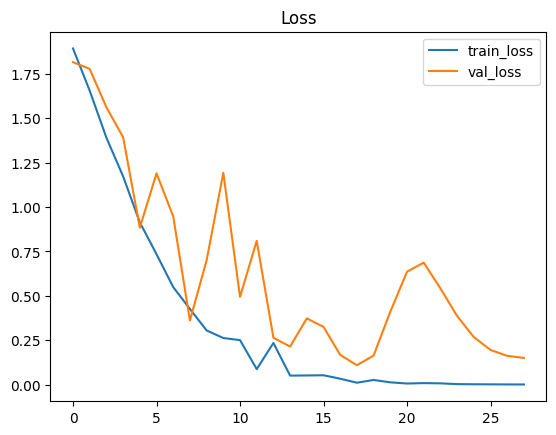

In [ ]:
#Visualization of taining and validation loss and accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
#Test Data
test_dir = "/content/drive/MyDrive/Ai ML/week5/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

#normalization
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [ ]:
#loss and accuracy on test data
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6333 - loss: 0.8061
Test Loss: 0.8061
Test Accuracy: 0.6333


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

     guarana       0.67      0.80      0.73         5
        acai       0.60      0.60      0.60         5
    graviola       0.62      1.00      0.77         5
     cupuacu       0.00      0.00      0.00         5
     pupunha       0.56      1.00      0.71         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.63        30
   macro avg       0.57      0.63      0.56        30
weighted avg       0.57      0.63      0.56        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Week 6

### Task 1: Implement Deeper Model with BN and Dropout & Data Augmentation

In [ ]:
# Define new image dimensions for the deeper model
new_img_height = 224
new_img_width = 224

# Re-create datasets with new image sizes and without initial rescaling
new_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(new_img_height, new_img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

new_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(new_img_height, new_img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Configure datasets for performance (no dataset-level augmentation or rescaling here, as it's in the model)
new_train_ds = new_train_ds.cache().prefetch(buffer_size=AUTOTUNE)
new_val_ds = new_val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"New training dataset created with image size: {new_img_height}x{new_img_width}")
print(f"New validation dataset created with image size: {new_img_height}x{new_img_width}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
New training dataset created with image size: 224x224
New validation dataset created with image size: 224x224


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense, Lambda

# Data augmentation layers as specified by the user
model_data_augmentation_layers = [
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
]

def model_data_augmentation(images):
    for layer in model_data_augmentation_layers:
        images = layer(images)
    return images

new_num_classes = len(classes)

new_model = Sequential([
    # Data augmentation applied using Lambda layer
    Lambda(model_data_augmentation, input_shape=(new_img_height, new_img_width, 3)),
    # Rescaling layer to normalize pixel values (moved into the model)
    tf.keras.layers.Rescaling(1./255),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the output of the last Conv2D layer
    Flatten(),

    # First Fully Connected Layer
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Second Fully Connected Layer
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Third Fully Connected Layer
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Fourth Fully Connected Layer
    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer with num_classes neurons
    Dense(new_num_classes, activation='softmax')
])

new_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [ ]:
# Compile the new model
new_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the new model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

new_checkpoint = ModelCheckpoint("best_new_model.h5", save_best_only=True)
new_early_stop = EarlyStopping(patience=10, restore_best_weights=True)

new_history = new_model.fit(
    new_train_ds,
    validation_data=new_val_ds,
    epochs=250,
    batch_size=16, # Using the original batch_size as a default, can be adjusted
    callbacks=[new_checkpoint, new_early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1736 - loss: 2.5194

3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step - accuracy: 0.2083 - loss: 2.4255 - val_accuracy: 0.0000e+00 - val_loss: 2.2937
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2454 - loss: 2.1842

3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step - accuracy: 0.2361 - loss: 2.1851 - val_accuracy: 0.0000e+00 - val_loss: 2.2724
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.2222 - loss: 2.3324 - val_accuracy: 0.0000e+00 - val_loss: 2.4011
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.1806 - loss: 2.2953 - val_accuracy: 0.0000e+00 - val_loss: 2.5375
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.2083 - loss: 2.1981 - val_accuracy: 0.0000e+00 - val_loss: 2.5395
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.2639 - loss: 2.0861 - val_accuracy: 0.0000e+00 - val_loss: 2.5134
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.1667 - loss: 2.2261 - val_accuracy: 0.0000e+00 - val_loss: 2.4561
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.2778 - loss: 1.9660 - val_accuracy: 0.0000e+00 - val_loss: 2.4179
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1343 - loss: 2.2052

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.1528 - loss: 2.1739 - val_accuracy: 0.0000e+00 - val_loss: 2.2533
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2054 - loss: 2.4440  

3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 7s/step - accuracy: 0.1944 - loss: 2.3790 - val_accuracy: 0.0000e+00 - val_loss: 2.1053
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1852 - loss: 2.2043

3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step - accuracy: 0.1806 - loss: 2.2158 - val_accuracy: 0.0000e+00 - val_loss: 2.0341
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.2222 - loss: 1.9582 - val_accuracy: 0.0000e+00 - val_loss: 2.0597
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.3056 - loss: 1.9452 - val_accuracy: 0.0000e+00 - val_loss: 2.0980
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.3194 - loss: 1.9130 - val_accuracy: 0.0000e+00 - val_loss: 2.1324
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.3333 - loss: 1.7897 - val_accuracy: 0.0000e+00 - val_loss: 2.1514
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.2917 - loss: 2.0450 - val_accuracy: 0.0000e+00 - val_loss: 2.2253
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.2500 - loss: 1.8799 - val_accuracy: 0.0000e+00 - val_loss: 2.2711
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.3611 - loss: 1.8001 - val_accuracy: 0.0

In [ ]:
# Evaluate the new Model on validation data
new_test_loss, new_test_acc = new_model.evaluate(new_val_ds)
print("New Model Test Loss (Validation):", new_test_loss)
print("New Model Test Accuracy (Validation):", new_test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step - accuracy: 0.0000e+00 - loss: 2.0341
New Model Test Loss (Validation): 2.0340943336486816
New Model Test Accuracy (Validation): 0.0


In [ ]:
# Save the new Model
new_model.save("week6_cnn_new_model.h5")

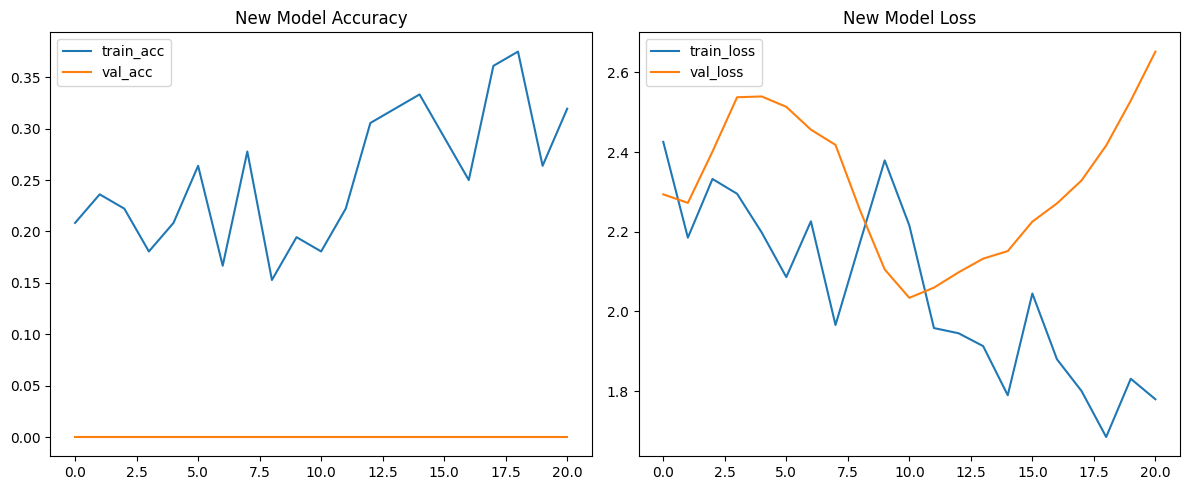

In [ ]:
# Visualization of new training and validation loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(new_history.history['accuracy'], label='train_acc')
plt.plot(new_history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("New Model Accuracy")

plt.subplot(1, 2, 2)
plt.plot(new_history.history['loss'], label='train_loss')
plt.plot(new_history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("New Model Loss")

plt.tight_layout()
plt.show()

In [ ]:
# Test Data for the new model
# Re-create test_ds with new image sizes and without initial rescaling
new_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(new_img_height, new_img_width),
    batch_size=batch_size,
    shuffle=False
)

# Configure dataset for performance
new_test_ds = new_test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"New test dataset created with image size: {new_img_height}x{new_img_width}")

Found 30 files belonging to 6 classes.
New test dataset created with image size: 224x224


In [ ]:
# Loss and accuracy on new test data
new_test_loss_final, new_test_acc_final = new_model.evaluate(new_test_ds)

print(f"New Model Test Loss: {new_test_loss_final:.4f}")
print(f"New Model Test Accuracy: {new_test_acc_final:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1667 - loss: 1.8939
New Model Test Loss: 1.8939
New Model Test Accuracy: 0.1667


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

new_y_true = []
new_y_pred = []

for images, labels in new_test_ds:
    new_preds = new_model.predict(images)
    new_preds = np.argmax(new_preds, axis=1)

    new_y_true.extend(labels.numpy())
    new_y_pred.extend(new_preds)

print(classification_report(new_y_true, new_y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

     guarana       0.00      0.00      0.00         5
        acai       0.00      0.00      0.00         5
    graviola       0.17      1.00      0.29         5
     cupuacu       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
